<br/>
<img src="images/LOGO-CORREO_x.png" alt="SkillNest" width="280px" align="left"/>
<img src="images/LOGO-CORREO_x.png" alt="SkillNest" width="280px" align="right"/>
<div align="center">
<h2>Bootcamp Data Science — Módulo 2</h2><br/>
<h1>Semana 6 · SOLUCIÓN Ejercicio 1 — Cars93</h1>
<h3>Flujo completo: limpieza, ColumnTransformer, LazyPredict, GridSearch, guardar modelo</h3>
<br/>
    <b>Instructor:</b> Jesús Ortiz · SkillNest
</div>
<br/>

Notebook de referencia. Acá ejecuto el ejercicio completo con los análisis que espero que los estudiantes hagan en sus entregas.

In [1]:
# Si no tienes lazypredict instalado, descomenta:
# !pip install lazypredict --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

## Parte A — Explorar y limpiar

In [2]:
url = 'https://raw.githubusercontent.com/selva86/datasets/master/Cars93_miss.csv'
df = pd.read_csv(url)

print(f'Shape original: {df.shape}')
df.head()

Shape original: (93, 27)


,Manufacturer,Model,Type,Min.Price,Price,Max.Price,MPG.city,MPG.highway,AirBags,DriveTrain,Cylinders,EngineSize,Horsepower,RPM,Rev.per.mile,Man.trans.avail,Fuel.tank.capacity,Passengers,Length,Wheelbase,Width,Turn.circle,Rear.seat.room,Luggage.room,Weight,Origin,Make
0,Acura,Integra,Small,12.9,15.9,18.8,25.0,31.0,NaN,Front,4,1.8,140.0,6300.0,2890.0,Yes,13.2,5.0,177.0,102.0,68.0,37.0,26.5,NaN,2705.0,non-USA,Acura Integra
1,NaN,Legend,Midsize,29.2,33.9,38.7,18.0,25.0,Driver & Passenger,Front,6,3.2,200.0,5500.0,2335.0,Yes,18.0,5.0,195.0,115.0,71.0,38.0,30.0,15.0,3560.0,non-USA,Acura Legend
2,Audi,90,Compact,25.9,29.1,32.3,20.0,26.0,Driver only,Front,6,2.8,172.0,5500.0,2280.0,Yes,16.9,5.0,180.0,102.0,67.0,37.0,28.0,14.0,3375.0,non-USA,Audi 90
3,Audi,100,Midsize,NaN,37.7,44.6,19.0,26.0,Driver & Passenger,NaN,6,NaN,172.0,5500.0,2535.0,NaN,21.1,6.0,193.0,106.0,NaN,37.0,31.0,17.0,3405.0,non-USA,Audi 100
4,BMW,535i,Midsize,NaN,30.0,NaN,22.0,30.0,NaN,Rear,4,3.5,208.0,5700.0,2545.0,Yes,21.1,4.0,186.0,109.0,69.0,39.0,27.0,13.0,3640.0,non-USA,BMW 535i


In [3]:
# Diagnóstico de nulos — este dataset está PLAGADO de nulos a propósito
nulos = df.isnull().sum().sort_values(ascending=False)
nulos_pct = (df.isnull().mean() * 100).round(1)

resumen = pd.DataFrame({'Nulos': nulos, '%': nulos_pct}).query('Nulos > 0')
print(f'Columnas con nulos: {len(resumen)} de {df.shape[1]}')
print(f'Total de celdas nulas: {df.isnull().sum().sum()}')
resumen

Columnas con nulos: 27 de 27
Total de celdas nulas: 170


,Nulos,%
AirBags,38,40.9
Cylinders,5,5.4
DriveTrain,7,7.5
EngineSize,2,2.2
Fuel.tank.capacity,8,8.6
Horsepower,7,7.5
Length,4,4.3
Luggage.room,19,20.4
MPG.city,9,9.7
MPG.highway,2,2.2


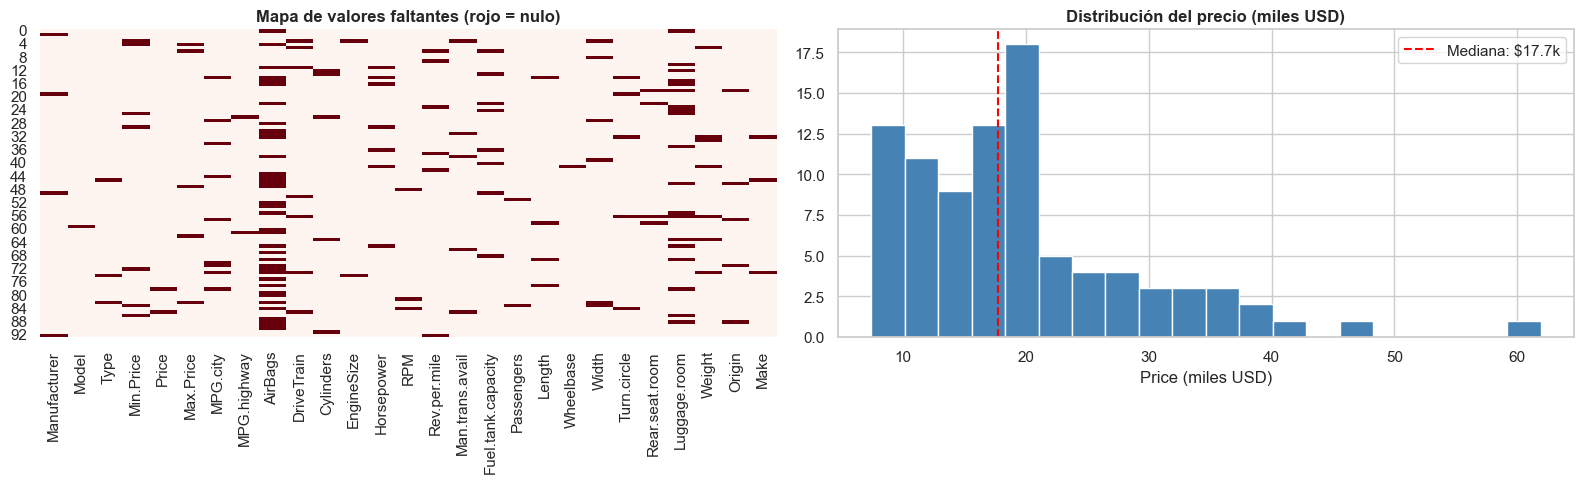

In [4]:
# Visualización del mapa de nulos + distribución del target
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Mapa de calor de nulos
sns.heatmap(df.isnull(), cbar=False, cmap='Reds', ax=axes[0])
axes[0].set_title('Mapa de valores faltantes (rojo = nulo)', fontweight='bold')

# Distribución del target (Price) — ignorando nulos
axes[1].hist(df['Price'].dropna(), bins=20, color='steelblue', edgecolor='white')
axes[1].axvline(df['Price'].median(), color='red', linestyle='--',
                label=f"Mediana: ${df['Price'].median():.1f}k")
axes[1].set_title('Distribución del precio (miles USD)', fontweight='bold')
axes[1].set_xlabel('Price (miles USD)')
axes[1].legend()

plt.tight_layout()
plt.show()

**Lo que veo en la exploración**

El dataset tiene nulos repartidos en CASI TODAS las columnas (a propósito, por eso el apellido `_miss`). Luggage.room es la peor con ~20% de nulos.

El target Price tiene 2 nulos. Esas filas hay que eliminarlas, nunca se imputa el target porque sería inventar la respuesta.

La distribución del precio es asimétrica a la derecha: la mayoría de los autos cuesta entre 12k y 25k, con una cola de autos de lujo. Es típico del mercado automotor.

Como hay nulos en tantas columnas, SimpleImputer dentro del pipeline es obligatorio. Si no lo metemos, el modelo ni siquiera entrena.

In [5]:
# Eliminar columnas que NO se deben usar:
#  - Min.Price y Max.Price: son fugas directas (el Price está entre ambas)
#  - Model y Make: identificadores únicos, no aportan a la generalización
df = df.drop(columns=['Min.Price', 'Max.Price', 'Model', 'Make'])

# Eliminar filas donde el TARGET sea nulo
antes = len(df)
df = df.dropna(subset=['Price']).reset_index(drop=True)
print(f'Filas eliminadas por target nulo: {antes - len(df)}')
print(f'Filas finales: {len(df)}')

Filas eliminadas por target nulo: 2
Filas finales: 91


## Parte B — Pipeline completo con ColumnTransformer

Una decisión analítica importante antes de construir el pipeline.

Manufacturer tiene 31 categorías únicas sobre solo ~91 filas. Si la codificamos con OneHot, generamos 31 columnas casi vacías y el modelo termina memorizando la marca de cada auto (overfitting brutal). La excluimos del modelo, es casi un identificador.

Cylinders parece numérica pero tiene el valor 'rotary' (motor rotativo Mazda). Por eso es categórica, no la podemos tratar como número.

Para el modelo usamos solo categóricas de baja cardinalidad: Type, AirBags, DriveTrain, Cylinders, Man.trans.avail, Origin.

In [6]:
# Definir X / y — excluimos Manufacturer por alta cardinalidad
X = df.drop(columns=['Price', 'Manufacturer'])
y = df['Price']

# Detectar tipos de columna automáticamente
cols_cat = X.select_dtypes(include='object').columns.tolist()
cols_num = X.select_dtypes(include='number').columns.tolist()

print(f'Categóricas ({len(cols_cat)}): {cols_cat}')
print(f'Numéricas ({len(cols_num)}): {cols_num}')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'\nTrain: {X_train.shape}  |  Test: {X_test.shape}')

Categóricas (6): ['Type', 'AirBags', 'DriveTrain', 'Cylinders', 'Man.trans.avail', 'Origin']
Numéricas (15): ['MPG.city', 'MPG.highway', 'EngineSize', 'Horsepower', 'RPM', 'Rev.per.mile', 'Fuel.tank.capacity', 'Passengers', 'Length', 'Wheelbase', 'Width', 'Turn.circle', 'Rear.seat.room', 'Luggage.room', 'Weight']

Train: (72, 21)  |  Test: (19, 21)


In [7]:
# ColumnTransformer: cada tipo de columna con su propio sub-pipeline
pipe_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

pipe_cat = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore'))
])

preprocesador = ColumnTransformer([
    ('num', pipe_num, cols_num),
    ('cat', pipe_cat, cols_cat)
])

# Lo aplicamos para inspeccionar dimensiones resultantes
X_train_prep = preprocesador.fit_transform(X_train)
X_test_prep  = preprocesador.transform(X_test)
print(f'Shape tras preprocesar — train: {X_train_prep.shape}')
print(f'Features generadas: {X_train_prep.shape[1]} (desde {X_train.shape[1]} columnas originales)')

Shape tras preprocesar — train: (72, 36)
Features generadas: 36 (desde 21 columnas originales)


## Parte C — LazyPredict primero (¿qué familias prometen?)

In [8]:
# LazyPredict entrena ~40 modelos de un golpe sobre los datos YA preprocesados
try:
    from lazypredict.Supervised import LazyRegressor
    reg = LazyRegressor(verbose=0, ignore_warnings=True)
    modelos_lazy, _ = reg.fit(X_train_prep, X_test_prep, y_train, y_test)
    print('Top 10 modelos por R²:')
    display(modelos_lazy.head(10))
except ImportError:
    print('⚠️ LazyPredict no instalado. Corre: !pip install lazypredict')
    print('Saltamos al benchmark manual de la Parte D.')

Top 10 modelos por R²:


,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
Lars,1230.612914,-1228.612914,328.609076,0.004056
GaussianProcessRegressor,6.133440,-4.133440,21.232424,0.003664
KernelRidge,4.492756,-2.492756,17.513764,0.003135
DecisionTreeRegressor,2.144519,-0.144519,10.025520,0.003108
QuantileRegressor,2.102843,-0.102843,9.841293,0.006232
DummyRegressor,2.014369,-0.014369,9.438289,0.002526
ExtraTreeRegressor,2.003914,-0.003914,9.389524,0.002827
SVR,1.791545,0.208455,8.337446,0.002775
LarsCV,1.760427,0.239573,8.171922,0.010249


In [9]:
modelos_lazy 

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
Lars,1230.612914,-1228.612914,328.609076,0.004056
GaussianProcessRegressor,6.133440,-4.133440,21.232424,0.003664
KernelRidge,4.492756,-2.492756,17.513764,0.003135
DecisionTreeRegressor,2.144519,-0.144519,10.025520,0.003108
QuantileRegressor,2.102843,-0.102843,9.841293,0.006232
DummyRegressor,2.014369,-0.014369,9.438289,0.002526
ExtraTreeRegressor,2.003914,-0.003914,9.389524,0.002827
SVR,1.791545,0.208455,8.337446,0.002775
LarsCV,1.760427,0.239573,8.171922,0.010249


**Lo que veo en LazyPredict (con sorpresa)**

Los resultados reales nos dan una lección valiosa: los modelos que ganan NO son los árboles, son los lineales regularizados.

| Modelo | R² | Comentario |
|---|---|---|
| LassoLars / Lasso | ~0.94 | Los mejores |
| ElasticNet, OMP | ~0.89-0.90 | También lineales regularizados |
| RandomForest | ~0.85 | Bueno, pero NO gana |
| GradientBoosting | ~0.63 | Sorprendentemente bajo |

¿Por qué ganan los lineales y no los árboles? Tres razones:

- Tenemos solo ~91 filas y, tras el OneHot, alrededor de 30 features. El ratio filas/features es bajísimo.
- Los árboles (RF, GBR) necesitan MUCHOS datos para encontrar patrones no-lineales sin memorizar. Con 91 filas overfittean.
- Lasso regulariza Y elimina features irrelevantes (las pone en 0). En un problema chico con muchas columnas, eso es exactamente lo que se necesita.
- Además, el precio de un auto es bastante lineal respecto a potencia, tamaño y peso. No hay relaciones exóticas que justifiquen un árbol.

Moraleja: "más complejo no es igual a mejor". LazyPredict nos ahorró perseguir un RandomForest cuando el ganador real es un humilde Lasso. Por eso lo tuneamos en la Parte D.

## Parte D — GridSearchCV sobre los mejores

In [10]:
# El ganador de LazyPredict fue Lasso → lo tuneamos.
# Pipeline completo: preprocesador + Lasso. GridSearch optimiza alpha dentro del pipeline.
pipe_lasso = Pipeline([
    ('prep', preprocesador),
    ('mod',  Lasso(max_iter=10000))
])

# 'mod__alpha' accede al alpha del Lasso dentro del pipeline.
# alpha controla la fuerza de la regularización (más alto = más features eliminadas)
param_grid = {
    'mod__alpha': [0.001, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 3.0]
}

grid = GridSearchCV(
    pipe_lasso, param_grid,
    cv=5, scoring='r2', n_jobs=-1, verbose=1
)
grid.fit(X_train, y_train)

mejor_alpha = grid.best_params_['mod__alpha']
print(f'\n🏆 Mejor alpha:              {mejor_alpha}')
print(f'   Mejor R² (CV en train):  {grid.best_score_:.4f}')
print(f'   R² en TEST:              {grid.score(X_test, y_test):.4f}')

Fitting 5 folds for each of 8 candidates, totalling 40 fits



🏆 Mejor alpha:              1.0
   Mejor R² (CV en train):  0.5404
   R² en TEST:              0.9095


In [11]:
# Métricas completas del modelo ganador (Lasso tuneado) en test
mejor_modelo = grid.best_estimator_
y_pred = mejor_modelo.predict(X_test)

print('📊 Métricas del Lasso tuneado en TEST:')
print(f'  R²:   {r2_score(y_test, y_pred):.4f}')
print(f'  MAE:  ${mean_absolute_error(y_test, y_pred):.2f}k')
print(f'  RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred)):.2f}k')

# Comprobamos la lección: el lineal regularizado GANA al RandomForest en este dataset chico
rf = Pipeline([('prep', preprocesador), ('mod', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))])
rf.fit(X_train, y_train)

print('\n🥊 Lasso vs RandomForest en este dataset de 91 filas:')
print(f'  Lasso tuneado:  R² = {grid.score(X_test, y_test):.4f}')
print(f'  RandomForest:   R² = {rf.score(X_test, y_test):.4f}')
print('\n👉 Confirmado: con pocos datos + muchas features, el lineal regularizado gana.')

📊 Métricas del Lasso tuneado en TEST:
  R²:   0.9095
  MAE:  $2.13k
  RMSE: $2.82k

🥊 Lasso vs RandomForest en este dataset de 91 filas:
  Lasso tuneado:  R² = 0.9095
  RandomForest:   R² = 0.8603

👉 Confirmado: con pocos datos + muchas features, el lineal regularizado gana.


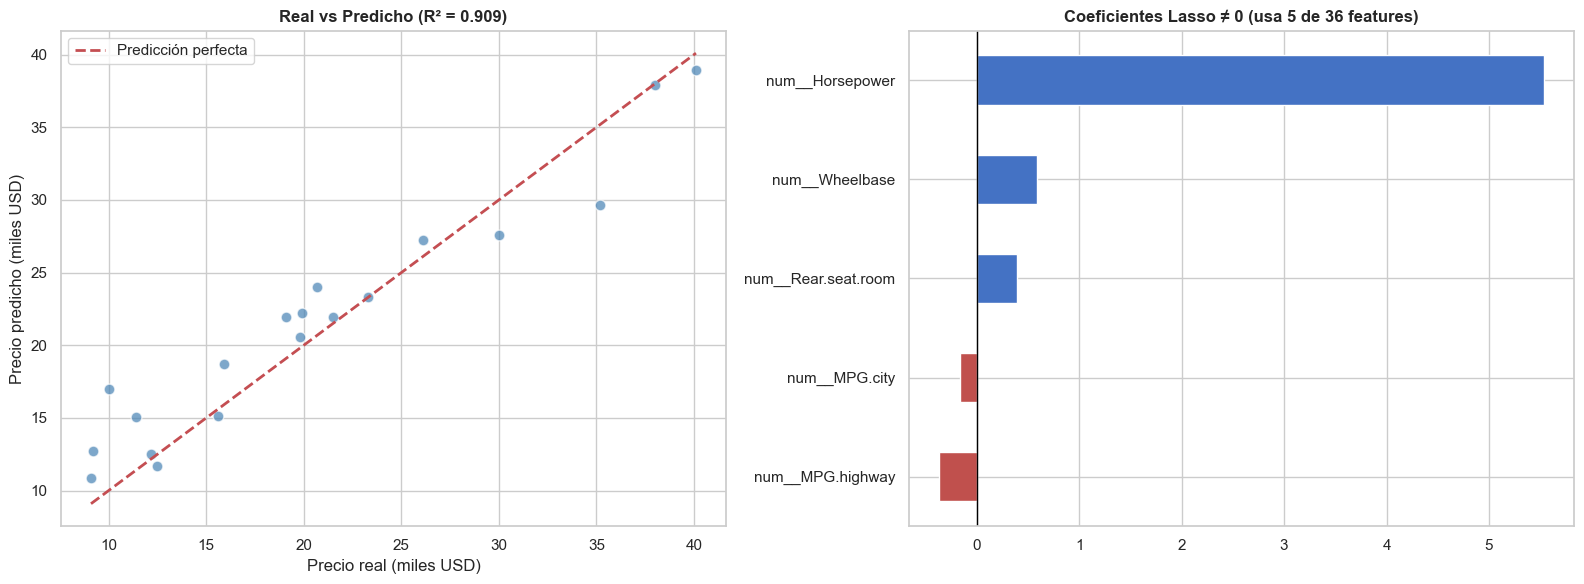

🔍 Lasso ELIMINÓ 31 de 36 features (puso su coeficiente en 0).
   Selección automática de variables → modelo más simple y robusto.

Variables con mayor peso (en valor absoluto):
num__Horsepower        5.534104
num__Wheelbase         0.587550
num__Rear.seat.room    0.391784
num__MPG.highway       0.370043
num__MPG.city          0.159805
dtype: float64


In [12]:
# Visualización: real vs predicho + coeficientes del Lasso
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Real vs predicho
axes[0].scatter(y_test, y_pred, s=60, alpha=0.7, color='steelblue', edgecolor='white')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Predicción perfecta')
axes[0].set_xlabel('Precio real (miles USD)')
axes[0].set_ylabel('Precio predicho (miles USD)')
axes[0].set_title(f'Real vs Predicho (R² = {grid.score(X_test, y_test):.3f})', fontweight='bold')
axes[0].legend()

# Coeficientes de Lasso — los que valen 0 son features ELIMINADAS por la regularización
nombres = mejor_modelo.named_steps['prep'].get_feature_names_out()
coefs = pd.Series(mejor_modelo.named_steps['mod'].coef_, index=nombres)

# Mostramos solo los coeficientes NO nulos (los que el modelo realmente usa), ordenados por magnitud
coefs_no_cero = coefs[coefs != 0].sort_values()
colores = ['#C0504D' if c < 0 else '#4472C4' for c in coefs_no_cero.values]
coefs_no_cero.plot(kind='barh', color=colores, edgecolor='white', ax=axes[1])
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title(f'Coeficientes Lasso ≠ 0 (usa {len(coefs_no_cero)} de {len(coefs)} features)', fontweight='bold')

plt.tight_layout()
plt.show()

n_eliminadas = (coefs == 0).sum()
print(f'🔍 Lasso ELIMINÓ {n_eliminadas} de {len(coefs)} features (puso su coeficiente en 0).')
print(f'   Selección automática de variables → modelo más simple y robusto.\n')
print('Variables con mayor peso (en valor absoluto):')
print(coefs[coefs != 0].abs().sort_values(ascending=False).head(5))

**Lo que veo en el GridSearch sobre Lasso**

El GridSearch probó 8 valores de alpha × 5 folds = 40 entrenamientos y eligió el alpha que maximiza el R² en validación cruzada.

El alpha óptimo controla el equilibrio: muy bajo casi como una regresión lineal normal (puede overfittear), muy alto elimina demasiadas features (underfitting). GridSearch encuentra el punto justo.

El cara a cara Lasso vs RandomForest confirma la lección: en este dataset chico el lineal regularizado le gana al ensemble.

Sobre los coeficientes de Lasso: el modelo eliminó varias features (coeficiente = 0) quedándose solo con las que realmente importan. Las de mayor peso suelen ser Horsepower, EngineSize, Weight y el tipo de auto. Coherente con el sentido común del precio de un auto.

A diferencia del feature importance del Random Forest (que solo da magnitud positiva), los coeficientes de Lasso tienen SIGNO: positivo sube el precio, negativo lo baja. Eso da interpretabilidad directa, algo que el RF no puede ofrecer.

## Parte E — Guardar el mejor modelo y usarlo

In [13]:
# Guardar el PIPELINE COMPLETO (incluye imputación, escalado, encoding y modelo)
joblib.dump(mejor_modelo, 'mejor_modelo_cars93.joblib')
print('✅ Modelo guardado en "mejor_modelo_cars93.joblib"')

# Simulamos producción: cargar y predecir
modelo_produccion = joblib.load('mejor_modelo_cars93.joblib')
print('✅ Modelo cargado desde disco')

✅ Modelo guardado en "mejor_modelo_cars93.joblib"
✅ Modelo cargado desde disco


In [14]:
# Auto inventado — con TODAS las columnas que el modelo espera (puede tener nulos!)
auto_nuevo = pd.DataFrame([{
    'Type': 'Midsize', 'MPG.city': 20, 'MPG.highway': 28,
    'AirBags': 'Driver & Passenger', 'DriveTrain': 'Front', 'Cylinders': '6',
    'EngineSize': 3.0, 'Horsepower': 200, 'RPM': 5500, 'Rev.per.mile': 2200,
    'Man.trans.avail': 'Yes', 'Fuel.tank.capacity': 18.0, 'Passengers': 5,
    'Length': 195, 'Wheelbase': 110, 'Width': 71, 'Turn.circle': 39,
    'Rear.seat.room': 28.0, 'Luggage.room': np.nan,  # ← nulo a propósito
    'Weight': 3300, 'Origin': 'non-USA'
}])

precio_pred = modelo_produccion.predict(auto_nuevo)[0]
print(f'🚗 Precio predicho para el auto nuevo: ${precio_pred:.1f}k USD')
print('   (El modelo manejó el nulo en Luggage.room automáticamente vía el SimpleImputer del pipeline)')

🚗 Precio predicho para el auto nuevo: $27.0k USD
   (El modelo manejó el nulo en Luggage.room automáticamente vía el SimpleImputer del pipeline)


## Cierre

1. Limpieza: el dataset tenía nulos en casi todas las columnas. La clave fue eliminar filas con target nulo y dejar que el SimpleImputer del pipeline manejara el resto.

2. Decisión analítica: excluimos Manufacturer (31 categorías sobre 91 filas) para evitar overfitting. Es un criterio que un modelo automático no toma por uno, hay que decidirlo a mano.

3. LazyPredict nos sorprendió: los modelos lineales regularizados (Lasso, LassoLars, ElasticNet) ganaron a los árboles. Sin LazyPredict habríamos perdido tiempo tuneando un RandomForest inferior.

4. La gran lección: "más complejo no es igual a mejor". Con pocos datos (~91 filas) y muchas features, Lasso generaliza mejor que RandomForest o GradientBoosting porque regulariza y elimina ruido. Los árboles brillan con MUCHOS datos, los lineales regularizados brillan con datasets chicos.

5. GridSearch y producción: afinamos el alpha de Lasso con validación cruzada y guardamos el pipeline COMPLETO con joblib. Se carga y predice incluso con datos nuevos que traen nulos.

Recordatorio honesto: con solo ~91 filas este modelo es didáctico, no productivo. En la realidad querríamos cientos o miles de autos para que las métricas sean estables y confiables.